# Reproducing results on the Sage paper

## Packages

In [1]:
! pip uninstall sage -y
! pip install -e ../

Found existing installation: sage 0.0.1
Uninstalling sage-0.0.1:
  Successfully uninstalled sage-0.0.1
Obtaining file:///home/nnarenraju/Research/sage
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sage (pyproject.toml) ... done
  Created wheel for sage: filename=sage-0.0.1-0.editable-py3-none-any.whl size=15110 sha256=2d85a7a3ab716f2893e5d154b188e0a7a43df9392786b20caf70c912e256d96a
  Stored in directory: /tmp/pip-ephem-wheel-cache-2z4p06xx/wheels/8f/4c/a7/916d6f92be3601810048e15e9869e7a33f29968eeac1d8298c
Successfully built sage

[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import h5py
import time
import torch
import numpy as np

import matplotlib.pyplot as plt

import lal
import lalsimulation as lalsim

In [3]:
def time_it(func, args, ntries=1000):
    start = time.time()
    for _ in range(ntries):
        func(args)
    time_taken = (time.time() - start)/ntries
    return time_taken

## Get Segments for Downloading Real Noise 

In [5]:
from sage.data.primer import TimelineQuery, get_all_detnames, get_all_runnames

In [ ]:
print(get_all_detnames())
print(get_all_runnames())

In [ ]:
tq = TimelineQuery(detector=["H1", "L1", "V1"], 
                   observing_run=["O3a",],
                   start = 1238166018,
                   end = 1238176018,
                   auto_clean_empty_timelines=True)
                                
tq.download_segments()

In [ ]:
tq.prune_segments(
    rm_short_segments = True,
    rm_min_duration = 22.0,
    rm_allevents = True,
    rm_window_length = 30,
)

In [ ]:
tq.timeline

## Download Segments from GWOSC

In [4]:
from sage.data.primer import DataReleaseDownloader

In [ ]:
drd = DataReleaseDownloader(
    segments_metadata=tq.timeline,
    save_parent_dir="./",
    noise_low_freq_cutoff = 15.0,
    minimum_segment_duration = 22.0,
    corrupt_trim_length = 0.2,
    max_download_retries = 15,
    retry_delay = 0.5,
    num_workers = 4,
    make_monolithic_file = True,
    sample_rate = 2048.0,
)

drd.download()

In [ ]:
foo = h5py.File('./data_release/data_L1_O3a.h5', 'r')
print(list(foo.keys()))

In [ ]:
foo['segments'].keys()

In [ ]:
# TODO: Find out why this is slightly smaller than expected
num = np.array(foo['segments/00000']).shape[0] + np.array(foo['segments/00001']).shape[0]
print((num+0)/2048.)

In [ ]:
foo['segments/00000'].attrs.keys()

## Get Noise PSD Estimates from Real Noise

In [ ]:
from sage.data.noise import GenerateRealNoise
from sage.data.primer import EstimatePSD
from sage.dsp.welch import WelchPSD
from sage.data.primer import NoBlackout, HardRatioBlackout

In [ ]:
noise_gen = GenerateRealNoise("./data_release/data_L1_O3a.h5")
noise_gen(2048)

In [ ]:
# Generating 20s of noise (on average over 10_000 tries takes 0.0019665 seconds)
# Generating 13s of noise (on average over 10_000 tries takes 0.0014012 seconds)
# Multiply this time by the number of detectors we will input into Sage
time_it(noise_gen, args=(int(13.*2048.),), ntries=10_000)

In [ ]:
class cfg:
    export_dir = "./export_dir"

class data_cfg:
    data_dir = "./data_dir"
    sample_rate = 2048.
    sample_length_in_seconds = 15

epsd = EstimatePSD(
    detector = 'H1',
    num_samples = 10,
    psd_method=WelchPSD(sample_rate=2048., nperseg_in_seconds=4),
    blackout_policy=NoBlackout(),
    store_raw_psds = True,
)

fiducial_psd, freqs = epsd(
    noise_source=noise_gen, 
    cfg=cfg(), 
    data_cfg=data_cfg()
)

plt.plot(freqs, fiducial_psd)
plt.xscale('log')
plt.yscale('log')
plt.xlim(15, 1024)
plt.show()

In [ ]:
class cfg:
    export_dir = "./export_dir"

class data_cfg:
    data_dir = "./data_dir"
    sample_rate = 2048.
    sample_length_in_seconds = 15

epsd = EstimatePSD(
    detector = 'H1',
    num_samples = 10,
    psd_method=WelchPSD(sample_rate=2048., nperseg_in_seconds=4),
    blackout_policy=HardRatioBlackout(4.0),
    store_raw_psds = True,
)

fiducial_psd, freqs = epsd(
    noise_source=noise_gen, 
    cfg=cfg(), 
    data_cfg=data_cfg()
)

plt.plot(freqs, fiducial_psd)
plt.xscale('log')
plt.yscale('log')
plt.xlim(15, 1024)
plt.ylim(1e-49, 1e-39)
plt.show()

## Sage Signal Generation

In [4]:
from sage.data.waveform import IMRPhenomPv2
from sage.core.conversions import mass1_mass2_to_mchirp_eta
from sage.data.waveform import phenom

In [5]:
# Generate the frequency grid
f_l = 20.
f_u = 2048.
del_f = 0.25
sample_length_in_s = 1./del_f
n = int(np.round((f_u - f_l) / del_f)) + 1
fs = f_l + del_f * torch.arange(
    n, device='cuda:0', dtype=torch.float64
)
f_ref = torch.tensor(f_l, dtype=torch.float64)

In [6]:
def get_waveform_kwargs(mass):
    # And finally lets generate the waveform (IMRPhenomPv2)!
    # Get a frequency domain waveform
    # source parameters
    m1_msun = mass
    m2_msun = mass - 1
    s1x = 0.0
    s1y = 0.0
    s1z = 0.0
    s2x = 0.0
    s2y = 0.0
    s2z = 0.0
    dist_mpc = 440.0
    tc = 0.0
    phiRef = 0.0
    incl = 0.0
    
    Mc, eta = mass1_mass2_to_mchirp_eta(m1_msun, m2_msun)
    theta_sage = torch.tensor([Mc, eta, s1x, s1y, s1z, s2x, s2y, s2z, dist_mpc, tc, phiRef, incl], device='cuda:0', dtype=torch.float64)

    return theta_sage

In [7]:
pv2const = phenom.PhenomConstants(device="cuda:0")

In [8]:
# Time taken for producing 1000 waveforms (same waveform)
num_waveforms = 1000
theta_sage = get_waveform_kwargs(30.0)

out = time_it(IMRPhenomPv2.gen_IMRPhenomPv2_hphc, (fs, theta_sage, f_ref, pv2const), ntries=num_waveforms)
print('Time taken to produce num_waveforms = {} with PyTorch = {} seconds'.format(num_waveforms, out))

Time taken to produce num_waveforms = 1000 with PyTorch = 0.04480853581428528 seconds


In [9]:
hp_sage, hc_sage = IMRPhenomPv2.gen_IMRPhenomPv2_hphc(fs, theta_sage, f_ref, pv2const)

/home/nnarenraju/Research/sage/.venv/lib64/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/nnarenraju/Research/sage/.venv/lib64/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


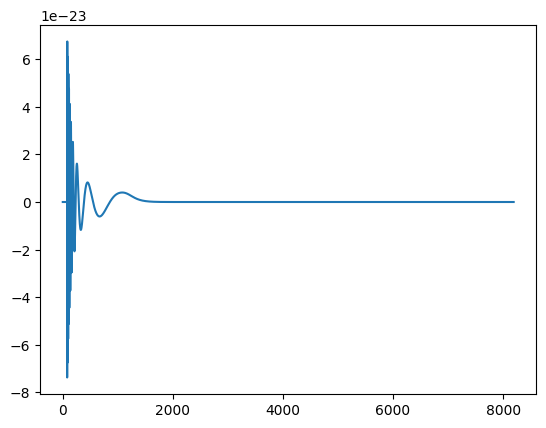

In [10]:
hp_sage = hp_sage.cpu().detach().numpy()
plt.plot(hp_sage)

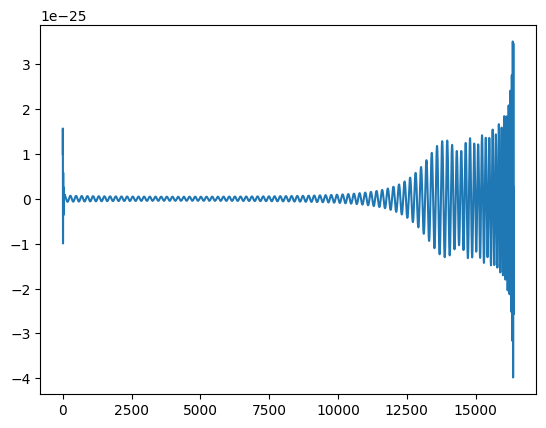

In [14]:
plt.plot(np.fft.irfft(hp_sage))

## Comparing Sage waveform generation with LAL

In [11]:
approximant = lalsim.SimInspiralGetApproximantFromString("IMRPhenomPv2")
m1_msun = 30.0 # In solar masses
m2_msun = 29.0
chi1 = 0.0
chi2 = 0.0
tc = 0.0 # Time of coalescence in seconds
phic = 0.0
dist_mpc = 440.0 # Distance to source in Mpc
inclination = 0.0 # Inclination Angle
m1_kg = m1_msun*lal.MSUN_SI
m2_kg = m2_msun*lal.MSUN_SI
distance = dist_mpc*1e6*lal.PC_SI

# Params for freq domain waveform
f_min = 20.0
f_max = 2048.0
f_ref = f_min
df = 0.25
sample_length_in_s = 1./df

hp, hc = lalsim.SimInspiralChooseFDWaveform(m1_kg, m2_kg,
                                            0., 0., chi1,
                                            0., 0., chi2,
                                            distance, inclination,
                                            phic, 0, 0., 0.,
                                            df, f_min, f_max, f_ref,
                                            None, approximant)
hp_lalsim = hp.data.data
hc_lalsim = hc.data.data

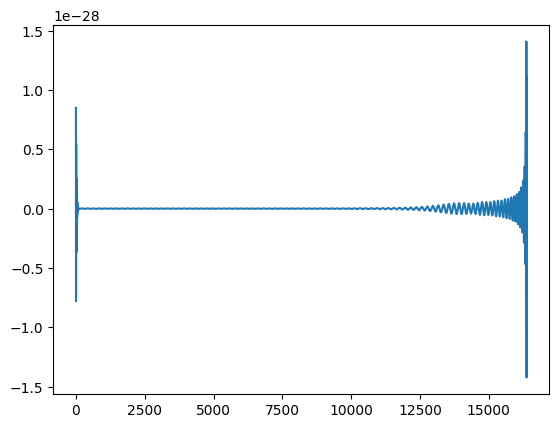

In [12]:
plt.plot(np.fft.irfft(hp_sage) - np.fft.irfft(hp_lalsim))

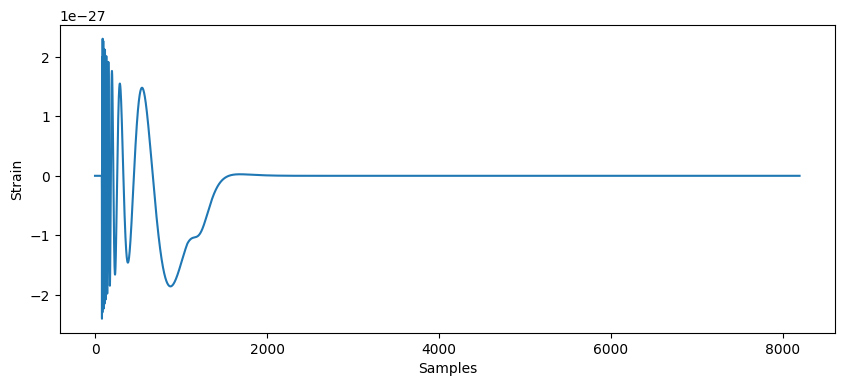

In [13]:
plt.figure(figsize=(10.0, 4.0))
plt.plot(hp_lalsim - hp_sage)
plt.xlabel('Samples')
plt.ylabel('Strain')
plt.show()

## Sage fully vectorised signal generation on torch.compile

In [4]:
from sage.data.waveform import IMRPhenomD as imr

In [5]:
IMRphenom = 'IMRPhenomD'

m1_msun = 20.0 # In solar masses
m2_msun = 19.0
chi1 = 0.0
chi2 = 0.0
tc = 0.0 # Time of coalescence in seconds
phic = 0.0
dist_mpc = 440.0 # Distance to source in Mpc
inclination = 0.0 # Inclination Angle
polarization_angle = 0 # Polarization angle

params = torch.tensor(
    [m1_msun, m2_msun, chi1, chi2, dist_mpc, tc, phic, inclination, polarization_angle],
    device='cuda:0',
    dtype=torch.float64
)

batch_size = 1
params_batch = params.unsqueeze(0).expand(batch_size, -1).clone()  # shape: (10, 9)

In [6]:
params_batch.shape

torch.Size([1, 9])

In [7]:
# Generate the frequency grid
f_l = 20.
f_u = 1024.
del_f = 1./20.
sample_length_in_s = 1./del_f
n = int(np.round((f_u - f_l) / del_f)) + 1
f = f_l + del_f * torch.arange(
    n, device='cuda:0', dtype=torch.float64
)
f = f.unsqueeze(0).expand(batch_size, -1).clone()

f_ref = torch.tensor(f_l, device='cuda:0', dtype=torch.float64)
f_ref = f_ref.unsqueeze(0).expand(batch_size, -1).clone()

In [8]:
f

tensor([[  20.0000,   20.0500,   20.1000,  ..., 1023.9000, 1023.9500,
         1024.0000]], device='cuda:0', dtype=torch.float64)

In [9]:
phd = imr.IMRPhenomD(f, f_ref)

In [10]:
hp_sage, hc_sage = phd(params_batch)

In [48]:
## With compile we take 0.0005 seconds for 500 waveforms (20 seconds at 2048 Hz)
start = time.time()
hp_sage, hc_sage = phd(params_batch)
print(f"Time taken to produce 500 IMRPhenomD waveforms = {time.time() - start}")

Time taken to produce 500 IMRPhenomD waveforms = 0.0005612373352050781


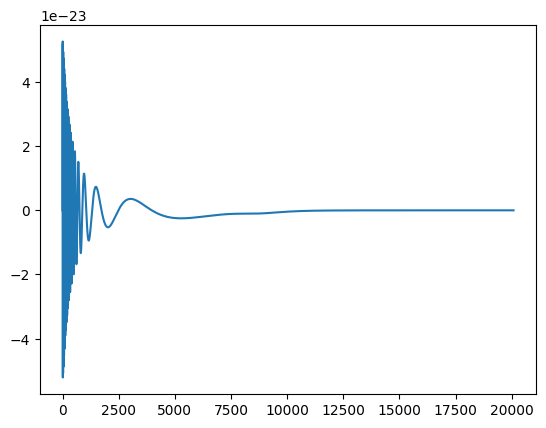

In [13]:
plt.plot(hc_sage[0].detach().cpu().numpy())

In [20]:
## With compile we take 0.000427 seconds PER waveform 20 seconds at 2048 Hz (1000 tries over batches of 500)
out = time_it(phd, (params_batch), ntries=1000)
print('Time taken to produce 1 waveform with PyTorch (without compile) = {} seconds'.format(round(out/500.,10)))

Time taken to produce 1 waveform with PyTorch (without compile) = 0.0003277965 seconds


IT'S ALIVE!!!

With torch.compile we take about 0.00032 seconds per waveform. So about 3124 waveforms per second. Each waveform is 20 seconds long at a sampling frequency of 2048 Hz. This is pretty good and should be more than fast enough for training Sage.

## Comparing fully vectorised Sage to LAL for IMRPhenomD

In [33]:
approximant = lalsim.SimInspiralGetApproximantFromString("IMRPhenomD")
m1_msun = 20.0 # In solar masses
m2_msun = 19.0
chi1 = 0.0
chi2 = 0.0
tc = 0.0 # Time of coalescence in seconds
phic = 0.0
dist_mpc = 440.0 # Distance to source in Mpc
inclination = 0.0 # Inclination Angle
m1_kg = m1_msun*lal.MSUN_SI
m2_kg = m2_msun*lal.MSUN_SI
distance = dist_mpc*1e6*lal.PC_SI

# Params for freq domain waveform
f_min = 20.0
f_max = 2048.0
f_ref = f_min
df = 0.25
sample_length_in_s = 1./df

hp, hc = lalsim.SimInspiralChooseFDWaveform(m1_kg, m2_kg,
                                            0., 0., chi1,
                                            0., 0., chi2,
                                            distance, inclination,
                                            phic, 0, 0., 0.,
                                            df, f_min, f_max, f_ref,
                                            None, approximant)
hp_lalsim = hp.data.data
hc_lalsim = hc.data.data

Observed sample rate = 4096.0


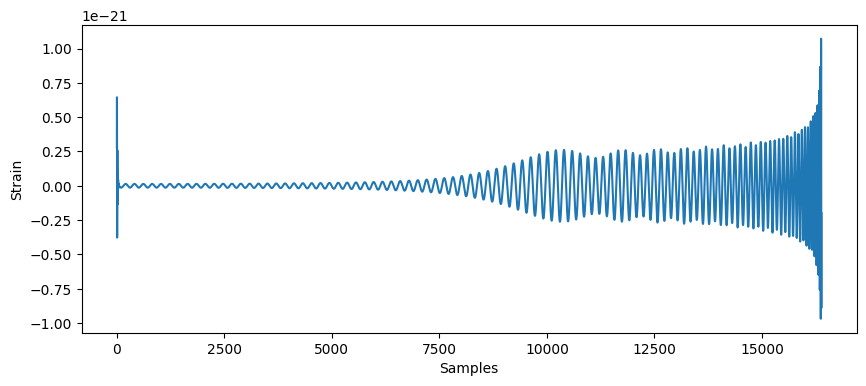

In [34]:
hp_lalsim_td = np.fft.irfft(hp_lalsim)
sample_rate = len(hp_lalsim_td)/sample_length_in_s
print('Observed sample rate = {}'.format(sample_rate))
hp_lalsim_td /= (1./sample_rate)

plt.figure(figsize=(10.0, 4.0))
plt.plot(hp_lalsim_td)
plt.xlabel('Samples')
plt.ylabel('Strain')
plt.show()

## Running Ripple with IMRPhenomD to compare Sage vectorised output

In [14]:
import jax
import jax.numpy as jnp

In [15]:
from ripplegw import ms_to_Mc_eta
from ripplegw.waveforms.IMRPhenomD import gen_IMRPhenomD_hphc

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [16]:
IMRphenom = 'IMRPhenomD'

m1_msun = 20.0 # In solar masses
m2_msun = 19.0
chi1 = 0.0
chi2 = 0.0
tc = 0.0 # Time of coalescence in seconds
phic = 0.0
dist_mpc = 440.0 # Distance to source in Mpc
inclination = 0.0 # Inclination Angle
polarization_angle = 0 # Polarization angle

Mc, eta = ms_to_Mc_eta(jnp.array([m1_msun, m2_msun]))

params = jnp.array([Mc, eta, chi1, chi2, dist_mpc, tc, phic, inclination, polarization_angle])

# Get a frequency domain waveform
f_l = 20.0
f_u = 1024.0
df = 1.0/20.0
f_ref = f_l
n = int(np.round((f_u - f_l) / df)) + 1

fs = f_l + df * np.arange(n)

In [17]:
def waveform(theta):
    hp, _ = gen_IMRPhenomD_hphc(fs, theta, f_ref)
    return hp

In [18]:
hp_ripple = waveform(params)

0.00019209419
(Array(93.704025, dtype=float32), Array(229.19824, dtype=float32), Array(72.88092, dtype=float32), Array(406.0984, dtype=float32), Array(458.39648, dtype=float32), Array(70.78179, dtype=float32))
First grad output with IIb raw phase; t0 = 253.33517456054688
[  20.     20.05   20.1  ... 1023.9  1023.95 1024.  ] 0.00019209419 [0.00384188 0.00385149 0.00386109 ... 0.19668524 0.19669485 0.19670445]
START OF PHASE
TF2 coeffs
1.0 0.0 6.440794 -50.265484 46.233517 154.92249 -1103.5801 1130.7903
464.76743 -326.0952380952381
[ 66.46202  65.87932  65.30061 ... 210.79446 210.82622 210.85785]
TF2 coeffs
1.0 0.0 6.440794 -50.265484 46.233517 154.92249 -1103.5801 1130.7903
464.76743 -326.0952380952381
-50.762814
get inspiral phase derivative = -559.0405883789062
47.16504
-557.48596
-1.5546265
-97.89987
[184.71341  182.99347  181.29037  ... -14.324387 -14.321541 -14.318703]
We are fine till here - 1
45.442154
116.0941
11.205776
116.0941
-0.5573273
-63.638958
[-10.151628 -10.287322 -10.4

/home/nnarenraju/Research/sage/.venv/lib64/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/nnarenraju/Research/sage/.venv/lib64/python3.9/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


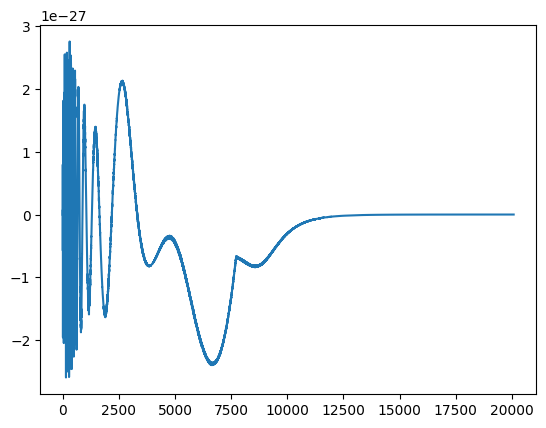

In [23]:
plt.plot(np.array(hp_ripple) - hp_sage[0].detach().cpu().numpy())